In [101]:
import os
from typing import TypedDict,Annotated
from langchain_core.messages import HumanMessage
from langgraph.graph.message import BaseMessage,add_messages
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpointEmbeddings , HuggingFaceEndpoint
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langgraph.prebuilt import ToolNode , tools_condition 
from langchain_core.retrievers import BaseRetriever
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from langchain_groq import ChatGroq
from langchain_core.tools import tool

load_dotenv()
os.environ['LANGCHAIN_PROJECT']="langgraph_rag"

In [102]:
llm = ChatGroq(model="openai/gpt-oss-20b",
    temperature=0.7)

In [103]:
pdf = PyPDFLoader(r"C:\projects\LangGraph\saransh_main (1).pdf")
pdf_data = pdf.load()
final_pdf_data = []
for doc in pdf_data:final_pdf_data.append(doc)
final_pdf_data

[Document(metadata={'producer': 'Microsoft® Word 2021', 'creator': 'Microsoft® Word 2021', 'creationdate': '2026-09-23T20:49:26+05:30', 'author': 'saransh bhardwaj', 'moddate': '2026-09-23T20:49:26+05:30', 'source': 'C:\\projects\\LangGraph\\saransh_main (1).pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Saransh Bhardwaj \nbhardwajsaransh08@gmail.com | +91 9466071454 | Linkedin: saransh-bhardwaj005  \nGithub: saransh-debug | LeetCode: saransh_1234_ \nProfile Summary \nFull Stack Developer with a strong focus on backend systems, AI -powered applications, and intelligent \nsoftware solutions. Experienced in building scalable, real -world products using the MERN stack and \nDjango, developing efficient APIs, integrating Large Language Models (LLMs), AI -driven features, and \nsemantic search capabilities to solve practical problems. I prioritize performance, clean architecture, and \nrapid delivery of end -to-end features. With a solid foundation in Data Structures a

In [104]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 400)
chunks = text_splitter.split_documents(final_pdf_data)
len(chunks)
print(chunks[:1])

[Document(metadata={'producer': 'Microsoft® Word 2021', 'creator': 'Microsoft® Word 2021', 'creationdate': '2026-09-23T20:49:26+05:30', 'author': 'saransh bhardwaj', 'moddate': '2026-09-23T20:49:26+05:30', 'source': 'C:\\projects\\LangGraph\\saransh_main (1).pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Saransh Bhardwaj \nbhardwajsaransh08@gmail.com | +91 9466071454 | Linkedin: saransh-bhardwaj005  \nGithub: saransh-debug | LeetCode: saransh_1234_ \nProfile Summary \nFull Stack Developer with a strong focus on backend systems, AI -powered applications, and intelligent \nsoftware solutions. Experienced in building scalable, real -world products using the MERN stack and \nDjango, developing efficient APIs, integrating Large Language Models (LLMs), AI -driven features, and \nsemantic search capabilities to solve practical problems. I prioritize performance, clean architecture, and \nrapid delivery of end -to-end features. With a solid foundation in Data Structures a

In [105]:
embeddings = HuggingFaceEndpointEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
vector_db = FAISS.from_documents(documents=chunks , embedding=embeddings)
vector_db

In [106]:

retriver = vector_db.as_retriever(search_type ='similarity',search_kwargs={"k":4})



In [107]:

class graph_state(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [108]:
graph = StateGraph(graph_state)

In [109]:
@tool()
def rag_Tool(query:str)->dict:
    '''Search the user's resume PDF (projects, skills, education, certifications) and return the most relevant passages'''
    
    result = retriver.invoke(query)
    
    content = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return( {
        "query":query,
        "content":content,
        "metadata":metadata
    })

tools = [rag_Tool]
llm_with_tools = llm.bind_tools(tools)


In [110]:
def chat_node(state:graph_state)->dict:
    data = state['messages']

    res = llm_with_tools.invoke(data)

    return {
        "messages":[res]
    }



tool_node = ToolNode(tools)


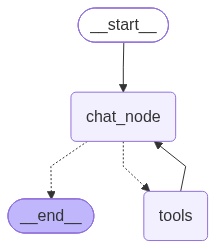

In [111]:
#CREATING NODES
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

#adding edges
graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chatbot = graph.compile()
chatbot

In [117]:
res = chatbot.invoke({"messages":[HumanMessage("what do you think my tech stack is suitable for what position")]})
res['messages'][-1]

AIMessage(content='**Your tech stack is a powerful blend of classic web‑stack skills and cutting‑edge generative‑AI tooling.  Below are the roles that most naturally align with the combination of technologies you’ve built, and why each one is a good fit.**\n\n| **Role** | **Core responsibilities** | **Why your stack fits** |\n|----------|---------------------------|------------------------|\n| **Generative‑AI / RAG Engineer** | Design, prototype, and ship AI‑powered applications that leverage LLMs, retrieval‑augmented generation, and semantic search. | • \u202fLangChain, LangGraph, RAG, LLMs, Prompt Engineering, FAISS, ChromaDB, and FastMCP give you the full stack for building and fine‑tuning AI pipelines.<br>• \u202fExperience building an AI‑powered code review system shows you can integrate external APIs, handle rate‑limiting, and orchestrate large‑scale inference. |\n| **Backend Engineer (Python/Django/REST)** | Build scalable, production‑ready APIs, services, and background workers